# IMDB Movie Reviews Sentiment Classification
## From Simple Baselines to Deep Learning

This notebook presents a compact, reproducible comparison of five approaches to binary sentiment classification:

1. Majority-class baseline
2. Keyword-based rules
3. Logistic Regression
4. Fully connected neural network
5. LSTM with learned word embeddings

The project uses the public Keras IMDB dataset: 25,000 training reviews and 25,000 test reviews. A fixed 5,000-review validation subset is taken from the training data for neural-network model selection.

All reported metrics and figures below are produced by this notebook. Random seeds are fixed for repeatability, although small numerical differences can still occur across hardware and TensorFlow builds.

## Step 1: Import Libraries and Load Data

In [1]:
# Install dependencies before running the notebook:
# python -m pip install -r requirements.txt

In [2]:
# Import libraries and configure reproducibility
import os
import random
import time
import warnings

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
warnings.filterwarnings("ignore")

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {SEED}")

TensorFlow version: 2.20.0
Random seed: 42


In [3]:
# Load IMDB dataset
# max_features = number of unique words to use (top 10000 most common words)
max_features = 10000
maxlen = 200  # Maximum review length (words)

print("Loading IMDB dataset...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nLabel distribution in training:")
print(f"  Positive reviews: {sum(y_train)}")
print(f"  Negative reviews: {len(y_train) - sum(y_train)}")

Loading IMDB dataset...


Training samples: 25000
Test samples: 25000

Label distribution in training:
  Positive reviews: 12500
  Negative reviews: 12500


In [4]:
# Let's see what the data looks like
# Reviews are encoded as sequences of word indices
print("Example review (as numbers):")
print(X_train[0][:50], "...")  # First 50 numbers of first review
print(f"\nLabel: {y_train[0]} ({'Positive' if y_train[0] == 1 else 'Negative'})")

Example review (as numbers):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447] ...

Label: 1 (Positive)


In [5]:
# Decode a review back to text to understand the data
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    """Convert number sequence back to text"""
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("Example decoded review:")
print(decode_review(X_train[0])[:500], "...")

Example decoded review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever ...


## Step 2: Data Preprocessing

We need to:
1. Pad sequences to same length (neural networks need fixed input size)
2. Create validation set from training data

In [6]:
# Pad sequences - make all reviews the same length
# If review is shorter than maxlen, add zeros at the beginning
# If review is longer than maxlen, cut it
X_train_padded = pad_sequences(X_train, maxlen=maxlen)
X_test_padded = pad_sequences(X_test, maxlen=maxlen)

print(f"Shape of training data: {X_train_padded.shape}")
print(f"Shape of test data: {X_test_padded.shape}")

Shape of training data: (25000, 200)
Shape of test data: (25000, 200)


In [7]:
# Split training data into train and validation sets
# We use 20% of training data for validation
val_size = 5000
X_val = X_train_padded[:val_size]
y_val = y_train[:val_size]
X_train_final = X_train_padded[val_size:]
y_train_final = y_train[val_size:]

print(f"Training set size: {len(X_train_final)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test_padded)}")

Training set size: 20000
Validation set size: 5000
Test set size: 25000


---
## Section 2: Simplest Baseline - Majority Class

The simplest "model" always predicts the most common class in the training data.
This gives us a baseline to compare against.

In [8]:
# Find the majority class in training data
positive_count = sum(y_train_final)
negative_count = len(y_train_final) - positive_count

print(f"Training data distribution:")
print(f"  Positive reviews: {positive_count} ({positive_count/len(y_train_final)*100:.1f}%)")
print(f"  Negative reviews: {negative_count} ({negative_count/len(y_train_final)*100:.1f}%)")

# Majority class
majority_class = 1 if positive_count > negative_count else 0
print(f"\nMajority class: {majority_class} ({'Positive' if majority_class == 1 else 'Negative'})")

Training data distribution:
  Positive reviews: 9954 (49.8%)
  Negative reviews: 10046 (50.2%)

Majority class: 0 (Negative)


In [9]:
# Majority Class Baseline - Always predict majority class
y_pred_majority = np.full(len(y_test), majority_class)

# Calculate metrics
accuracy_majority = accuracy_score(y_test, y_pred_majority)
precision_majority = precision_score(y_test, y_pred_majority)
recall_majority = recall_score(y_test, y_pred_majority)

print("="*50)
print("BASELINE 1: MAJORITY CLASS PREDICTOR")
print("="*50)
print(f"Accuracy:  {accuracy_majority:.4f} ({accuracy_majority*100:.2f}%)")
print(f"Precision: {precision_majority:.4f}")
print(f"Recall:    {recall_majority:.4f}")
print("="*50)

BASELINE 1: MAJORITY CLASS PREDICTOR
Accuracy:  0.5000 (50.00%)
Precision: 0.0000
Recall:    0.0000


---
## Section 3: Better Simple Baseline - Keyword-Based Rules

A smarter baseline: Count positive and negative keywords in each review.

In [10]:
# Define positive and negative keywords
# We'll use word indices from the IMDB dataset

# Get word indices for key sentiment words
positive_words = ['great', 'good', 'excellent', 'best', 'love', 'amazing', 'wonderful', 'perfect', 'beautiful', 'fantastic']
negative_words = ['bad', 'worst', 'terrible', 'awful', 'boring', 'waste', 'poor', 'horrible', 'stupid', 'disappointing']

# Convert words to indices (adding 3 because of reserved indices in IMDB dataset)
positive_indices = [word_index.get(word, 0) + 3 for word in positive_words if word in word_index]
negative_indices = [word_index.get(word, 0) + 3 for word in negative_words if word in word_index]

print(f"Positive word indices: {positive_indices[:5]}...")
print(f"Negative word indices: {negative_indices[:5]}...")

Positive word indices: [87, 52, 321, 118, 119]...
Negative word indices: [78, 249, 394, 373, 357]...


In [11]:
def keyword_predictor(review):
    """Predict sentiment based on keyword counts"""
    positive_count = sum(1 for word in review if word in positive_indices)
    negative_count = sum(1 for word in review if word in negative_indices)
    
    # If more positive keywords, predict positive (1)
    # If tie or more negative, predict negative (0)
    if positive_count > negative_count:
        return 1
    else:
        return 0

# Apply to test set
y_pred_keyword = np.array([keyword_predictor(review) for review in X_test])

# Calculate metrics
accuracy_keyword = accuracy_score(y_test, y_pred_keyword)
precision_keyword = precision_score(y_test, y_pred_keyword)
recall_keyword = recall_score(y_test, y_pred_keyword)

print("="*50)
print("BASELINE 2: KEYWORD-BASED RULES")
print("="*50)
print(f"Accuracy:  {accuracy_keyword:.4f} ({accuracy_keyword*100:.2f}%)")
print(f"Precision: {precision_keyword:.4f}")
print(f"Recall:    {recall_keyword:.4f}")
print("="*50)
print(f"\nImprovement over majority baseline: {(accuracy_keyword - accuracy_majority)*100:.2f}%")

BASELINE 2: KEYWORD-BASED RULES
Accuracy:  0.7230 (72.30%)
Precision: 0.7074
Recall:    0.7605

Improvement over majority baseline: 22.30%


---
## Section 4: Logistic Regression

A classic machine learning approach. We'll convert reviews to feature vectors (Bag of Words style).

In [12]:
# Convert sequences to compact binary bag-of-words vectors
def vectorize_sequences(sequences, dimension=max_features):
    """Return one uint8 presence feature per vocabulary item."""
    results = np.zeros((len(sequences), dimension), dtype=np.uint8)
    for row_index, sequence in enumerate(sequences):
        valid_indices = np.asarray(sequence)
        valid_indices = valid_indices[valid_indices < dimension]
        results[row_index, valid_indices] = 1
    return results

print("Vectorizing reviews...")
X_train_vec = vectorize_sequences(X_train[val_size:])
X_val_vec = vectorize_sequences(X_train[:val_size])
X_test_vec = vectorize_sequences(X_test)

total_megabytes = (
    X_train_vec.nbytes + X_val_vec.nbytes + X_test_vec.nbytes
) / (1024 ** 2)
print(f"Training vectors: {X_train_vec.shape}, dtype={X_train_vec.dtype}")
print(f"Total bag-of-words storage: {total_megabytes:.1f} MiB")

Vectorizing reviews...


Training vectors: (20000, 10000), dtype=uint8
Total bag-of-words storage: 476.8 MiB


In [13]:
# Train Logistic Regression
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
start = time.perf_counter()
log_reg.fit(X_train_vec, y_train_final)
elapsed_logreg = time.perf_counter() - start

y_pred_logreg = log_reg.predict(X_test_vec)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg, zero_division=0)
recall_logreg = recall_score(y_test, y_pred_logreg, zero_division=0)

print(f"Training time: {elapsed_logreg:.1f} seconds")
print(f"Accuracy:  {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall:    {recall_logreg:.4f}")

Training Logistic Regression...


Training time: 15.3 seconds
Accuracy:  0.8628
Precision: 0.8633
Recall:    0.8621


In [14]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['Negative', 'Positive']))

Confusion Matrix:
[[10793  1707]
 [ 1724 10776]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86     12500
    Positive       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



---
## Section 5: Simple Fully Connected Neural Network

A basic neural network with dense (fully connected) layers.

In [15]:
# Build a fully connected neural network
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

def build_simple_nn():
    model = Sequential([
        Input(shape=(max_features,)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(32, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

keras.backend.clear_session()
keras.utils.set_random_seed(SEED)
model_nn = build_simple_nn()
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,177 (2.45 MB)

 Trainable params: 642,177 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train with early stopping and restore the best validation-loss weights
early_stopping_nn = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

print("Training the fully connected neural network...")
start = time.perf_counter()
history_nn = model_nn.fit(
    X_train_vec,
    y_train_final,
    epochs=10,
    batch_size=512,
    validation_data=(X_val_vec, y_val),
    callbacks=[early_stopping_nn],
    verbose=1,
)
elapsed_nn = time.perf_counter() - start
best_epoch_nn = int(np.argmin(history_nn.history["val_loss"]) + 1)

print(f"Training time: {elapsed_nn:.1f} seconds")
print(f"Best epoch by validation loss: {best_epoch_nn}")

Training the fully connected neural network...


Epoch 1/10


 1/40 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5039 - loss: 0.7005

 5/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5198 - loss: 0.6951

 9/40 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5390 - loss: 0.6894

...

29/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9503 - loss: 0.1515

33/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9505 - loss: 0.1507

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9508 - loss: 0.1497

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9535 - loss: 0.1405 - val_accuracy: 0.8908 - val_loss: 0.3133


Training time: 4.9 seconds
Best epoch by validation loss: 3


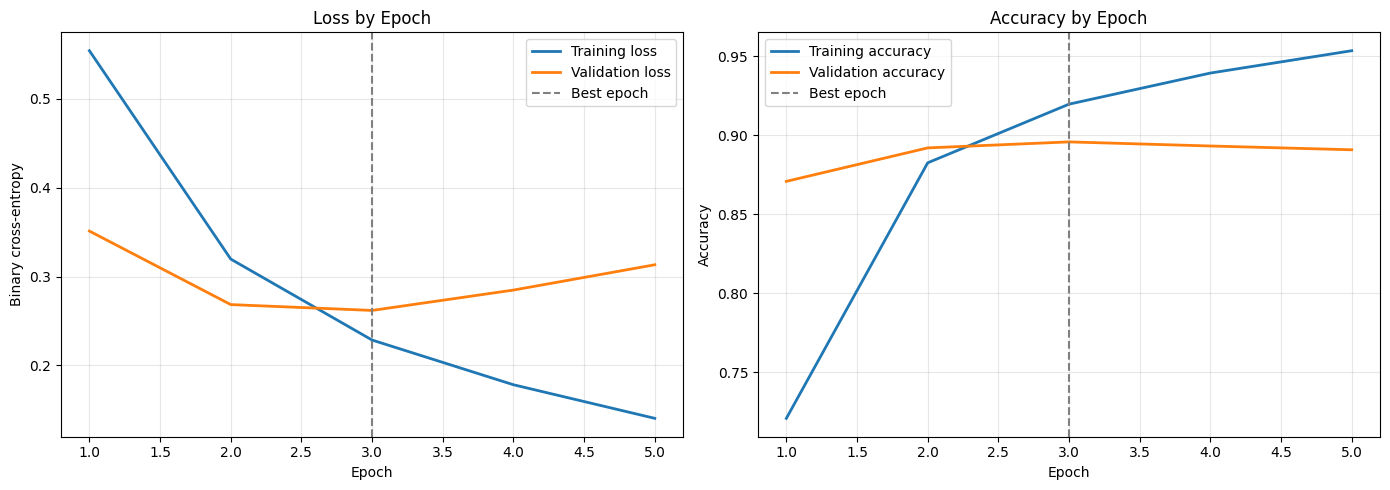

Validation loss begins rising after the best epoch, indicating overfitting. Early stopping restores the weights from the lowest validation loss.


In [17]:
# Plot training history
epochs_ran = range(1, len(history_nn.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history_nn.history["loss"], label="Training loss", linewidth=2)
axes[0].plot(epochs_ran, history_nn.history["val_loss"], label="Validation loss", linewidth=2)
axes[0].axvline(best_epoch_nn, color="gray", linestyle="--", label="Best epoch")
axes[0].set_title("Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history_nn.history["accuracy"], label="Training accuracy", linewidth=2)
axes[1].plot(epochs_ran, history_nn.history["val_accuracy"], label="Validation accuracy", linewidth=2)
axes[1].axvline(best_epoch_nn, color="gray", linestyle="--", label="Best epoch")
axes[1].set_title("Accuracy by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    "Validation loss begins rising after the best epoch, indicating overfitting. "
    "Early stopping restores the weights from the lowest validation loss."
)

In [18]:
# Evaluate the restored neural network on the untouched test set
y_pred_nn_prob = model_nn.predict(X_test_vec, verbose=0)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).ravel()

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn, zero_division=0)
recall_nn = recall_score(y_test, y_pred_nn, zero_division=0)

print("FULLY CONNECTED NEURAL NETWORK")
print(f"Accuracy:  {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall:    {recall_nn:.4f}")
print(f"Change from Logistic Regression: {(accuracy_nn - accuracy_logreg) * 100:+.2f} percentage points")

FULLY CONNECTED NEURAL NETWORK
Accuracy:  0.8863
Precision: 0.8877
Recall:    0.8844
Change from Logistic Regression: +2.35 percentage points


In [19]:
# Confusion Matrix for Neural Network
print("Classification Report for Neural Network:")
print(classification_report(y_test, y_pred_nn, target_names=['Negative', 'Positive']))

Classification Report for Neural Network:
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89     12500
    Positive       0.89      0.88      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



---
## Section 6: LSTM with Word Embeddings

The LSTM is included as a more advanced sequence model, not as an assumed improvement. Its result is compared honestly with the simpler approaches.

In [20]:
# Build an LSTM model with learned embeddings
from tensorflow.keras.layers import Embedding, LSTM

def build_lstm_model():
    model = Sequential([
        Input(shape=(maxlen,)),
        Embedding(max_features, 128),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

keras.backend.clear_session()
keras.utils.set_random_seed(SEED)
model_lstm = build_lstm_model()
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the LSTM with the same validation-based stopping policy
early_stopping_lstm = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

print("Training the LSTM...")
start = time.perf_counter()
history_lstm = model_lstm.fit(
    X_train_final,
    y_train_final,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_lstm],
    verbose=1,
)
elapsed_lstm = time.perf_counter() - start
best_epoch_lstm = int(np.argmin(history_lstm.history["val_loss"]) + 1)

print(f"Training time: {elapsed_lstm:.1f} seconds")
print(f"Best epoch by validation loss: {best_epoch_lstm}")

Training the LSTM...
Epoch 1/5


  1/157 ━━━━━━━━━━━━━━━━━━━━ 5:36 2s/step - accuracy: 0.4688 - loss: 0.6938

  2/157 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.4824 - loss: 0.6936

  3/157 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.4900 - loss: 0.6934

  4/157 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.4945 - loss: 0.6933

...

155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8691 - loss: 0.3215

156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8690 - loss: 0.3216

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8690 - loss: 0.3216

157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.8611 - loss: 0.3336 - val_accuracy: 0.8002 - val_loss: 0.4294


Training time: 75.3 seconds
Best epoch by validation loss: 1


In [22]:
# Evaluate the restored LSTM on the untouched test set
y_pred_lstm_prob = model_lstm.predict(X_test_padded, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).ravel()

accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm, zero_division=0)
recall_lstm = recall_score(y_test, y_pred_lstm, zero_division=0)

print("LSTM WITH EMBEDDINGS")
print(f"Accuracy:  {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall:    {recall_lstm:.4f}")

LSTM WITH EMBEDDINGS
Accuracy:  0.8367
Precision: 0.8268
Recall:    0.8519


---
## Final Summary: Comparison of All Models

In [23]:
# Build the canonical results table used by the notebook and figures
results = pd.DataFrame({
    "Model": [
        "Majority Class",
        "Keyword Rules",
        "Logistic Regression",
        "Fully Connected Neural Network",
        "LSTM",
    ],
    "Accuracy": [
        accuracy_majority,
        accuracy_keyword,
        accuracy_logreg,
        accuracy_nn,
        accuracy_lstm,
    ],
    "Precision": [
        precision_majority,
        precision_keyword,
        precision_logreg,
        precision_nn,
        precision_lstm,
    ],
    "Recall": [
        recall_majority,
        recall_keyword,
        recall_logreg,
        recall_nn,
        recall_lstm,
    ],
})

results_display = results.copy()
for metric in ["Accuracy", "Precision", "Recall"]:
    results_display[metric] = results_display[metric].map(lambda value: f"{value:.4f}")

best_row = results.loc[results["Accuracy"].idxmax()]
print(results_display.to_string(index=False))
print(f"\nBest observed test accuracy: {best_row['Model']} ({best_row['Accuracy']:.2%})")

                         Model Accuracy Precision Recall
                Majority Class   0.5000    0.0000 0.0000
                 Keyword Rules   0.7230    0.7074 0.7605
           Logistic Regression   0.8628    0.8633 0.8621
Fully Connected Neural Network   0.8863    0.8877 0.8844
                          LSTM   0.8367    0.8268 0.8519

Best observed test accuracy: Fully Connected Neural Network (88.63%)


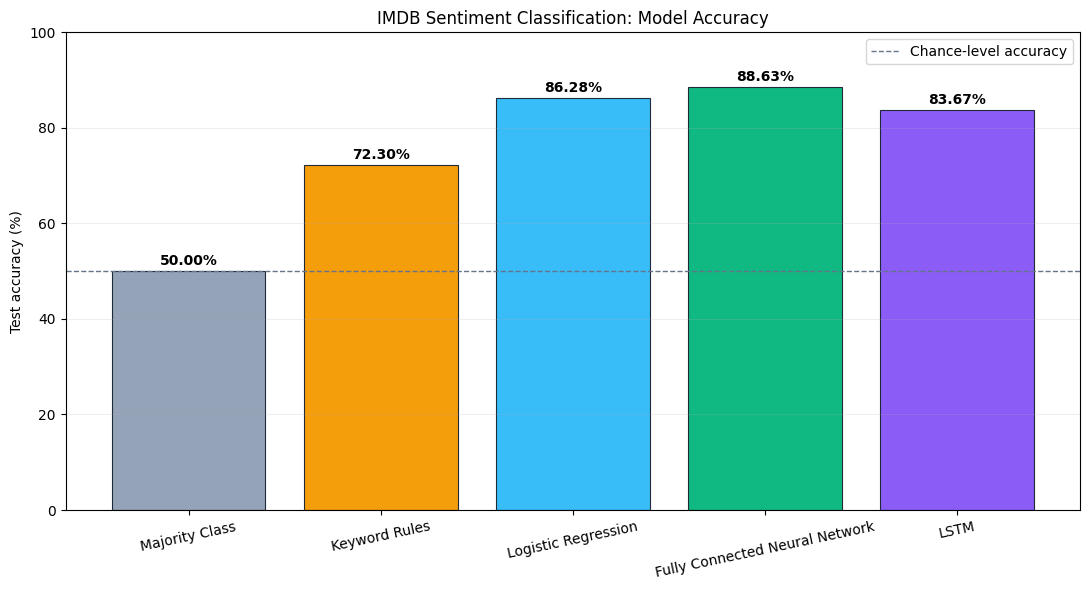

In [24]:
# Generate the canonical model-comparison figure directly from the results table
plot_results = results.copy()
plot_results["Accuracy (%)"] = plot_results["Accuracy"] * 100

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#94a3b8", "#f59e0b", "#38bdf8", "#10b981", "#8b5cf6"]
bars = ax.bar(
    plot_results["Model"],
    plot_results["Accuracy (%)"],
    color=colors,
    edgecolor="#1f2937",
    linewidth=0.8,
)

for bar, value in zip(bars, plot_results["Accuracy (%)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.axhline(50, color="#64748b", linestyle="--", linewidth=1, label="Chance-level accuracy")
ax.set_title("IMDB Sentiment Classification: Model Accuracy")
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=12)
ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Conclusions and Limitations

- The fully connected neural network is the strongest model in this experiment, but its gain over Logistic Regression is modest.
- Logistic Regression remains a strong and efficient baseline for high-dimensional bag-of-words features.
- The LSTM does not outperform the simpler models in this configuration. A more advanced architecture is not automatically a better fit, especially with short training and limited tuning.
- The dense network begins to overfit after its best validation epoch; early stopping limits this effect and restores the best observed weights.
- Results describe this fixed dataset split and implementation. Broader claims would require repeated runs, additional datasets, and systematic hyperparameter tuning.